In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

import tensorflow as tf
from tensorflow.keras import layers, models
from datetime import datetime

2000 images, 256x25g RGB

In [6]:
image_categories_path = '../data/images'
image_categories = [
    f'{image_categories_path}/{f}' 
    for f 
    in os.listdir(image_categories_path)
]

image_categories.remove(f'{image_categories_path}/.DS_Store')

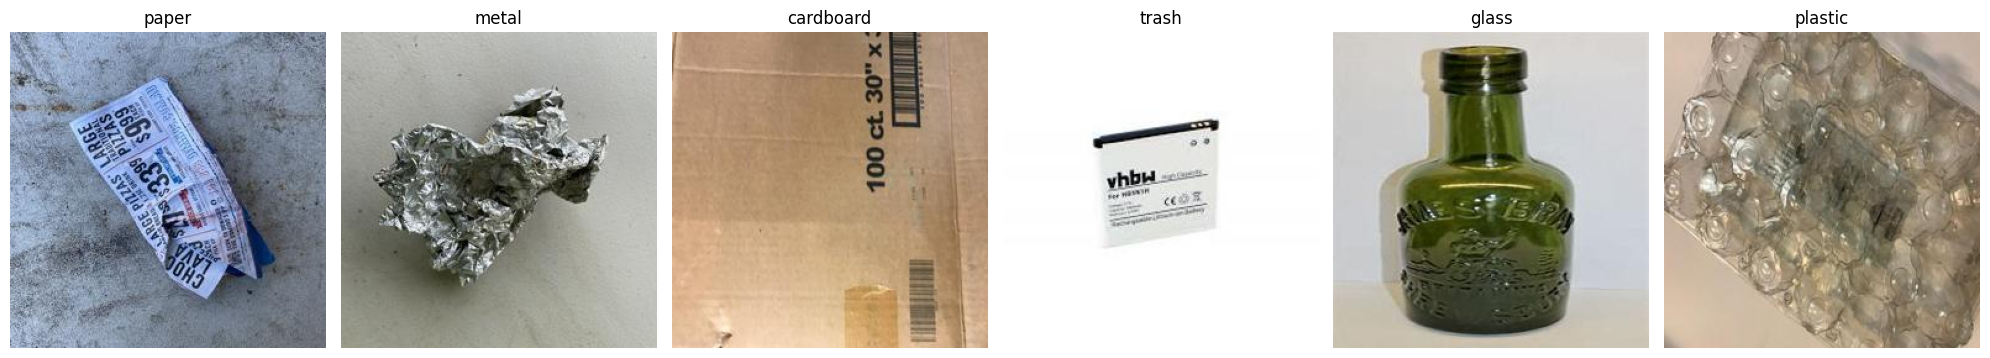

In [7]:
# Create a figure with 1 row and N columns (one for each category)
fig, axes = plt.subplots(1, len(image_categories), figsize=(20, 5))

for i, image_cat in enumerate(image_categories):
    # Get the list of images and pick the first one
    images = os.listdir(image_cat)
    img_path = os.path.join(image_cat, images[0])
    
    img = plt.imread(img_path)
    
    # Plot in the specific subplot slot
    axes[i].imshow(img)
    axes[i].set_title(image_cat.split('/')[-1]) # Set title as category name
    axes[i].axis('off') # Hide the x/y pixel coordinates

plt.tight_layout()
plt.show()

In [8]:
# Set parameters
img_height = 256
img_width = 256
batch_size = 64

# 1. Create the Training Dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    image_categories_path,
    validation_split=0.2,
    subset="training",
    seed=42,  # Seed ensures train/val don't overlap
    image_size=(img_height, img_width),
    batch_size=batch_size
)

# 2. Create the Validation Dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    image_categories_path,
    validation_split=0.2,
    subset="validation",
    seed=42,  # Must be the same seed as above!
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 13901 files belonging to 6 classes.
Using 11121 files for training.


2026-05-09 15:53:47.053774: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-05-09 15:53:47.053805: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-09 15:53:47.053812: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-09 15:53:47.053825: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-09 15:53:47.053835: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 13901 files belonging to 6 classes.
Using 2780 files for validation.


In [9]:
num_classes = len(train_ds.class_names)
print(f"Number of classes: {num_classes}")
print(f"Class names: {train_ds.class_names}")

class_names = train_ds.class_names

Number of classes: 6
Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [10]:
model = models.Sequential([
    # Notice: NO augmentation or rescaling here! We just define the input shape.
    layers.Input(shape=(256, 256, 3)),
    
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Block 3
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 4
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.GlobalAveragePooling2D(), 
    
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(), 
    layers.Dropout(0.4),          
    layers.Dense(num_classes, activation='softmax')
])

In [11]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [12]:
# Apply these to both train_ds and val_ds
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

### Plot

In [13]:
from IPython.display import clear_output

class LivePlotCallback(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        # Initialize lists to store metrics
        self.epochs = []
        self.history = {'accuracy': [], 'val_accuracy': [], 'loss': [], 'val_loss': []}

    def on_epoch_end(self, epoch, logs=None):
        # Store the metrics from the current epoch
        self.epochs.append(epoch + 1)
        for key in self.history.keys():
            self.history[key].append(logs.get(key))

        # Clear the previous chart to make room for the update
        clear_output(wait=True)
        
        # --- Your Custom Plotting Logic ---
        fig, ax = plt.subplots(2, 1, figsize=(12, 8))

        # Accuracy plot
        ax[0].plot(self.epochs, self.history['accuracy'], label='Train Accuracy', marker='.')
        ax[0].plot(self.epochs, self.history['val_accuracy'], label='Validation Accuracy', marker='.')
        ax[0].set_title('Model Accuracy')
        ax[0].set_ylabel('Accuracy')
        ax[0].set_xlabel('Epoch')
        ax[0].legend(loc='upper left')

        # Loss plot
        ax[1].plot(self.epochs, self.history['loss'], label='Train Loss', marker='.')
        ax[1].plot(self.epochs, self.history['val_loss'], label='Validation Loss', marker='.')
        ax[1].set_title('Model Loss')
        ax[1].set_ylabel('Loss')
        ax[1].set_xlabel('Epoch')
        ax[1].legend(loc='upper right')

        # Generic settings
        for a in ax:
            a.grid(color='lightgray', linestyle='--', linewidth=0.5)
            # a.set_xlim(1, max(self.epochs) if self.epochs else 1) # Optional: keep X-axis consistent
            for spine in ['top', 'right']:
                a.spines[spine].set_visible(False)
        
        plt.tight_layout()
        plt.show()

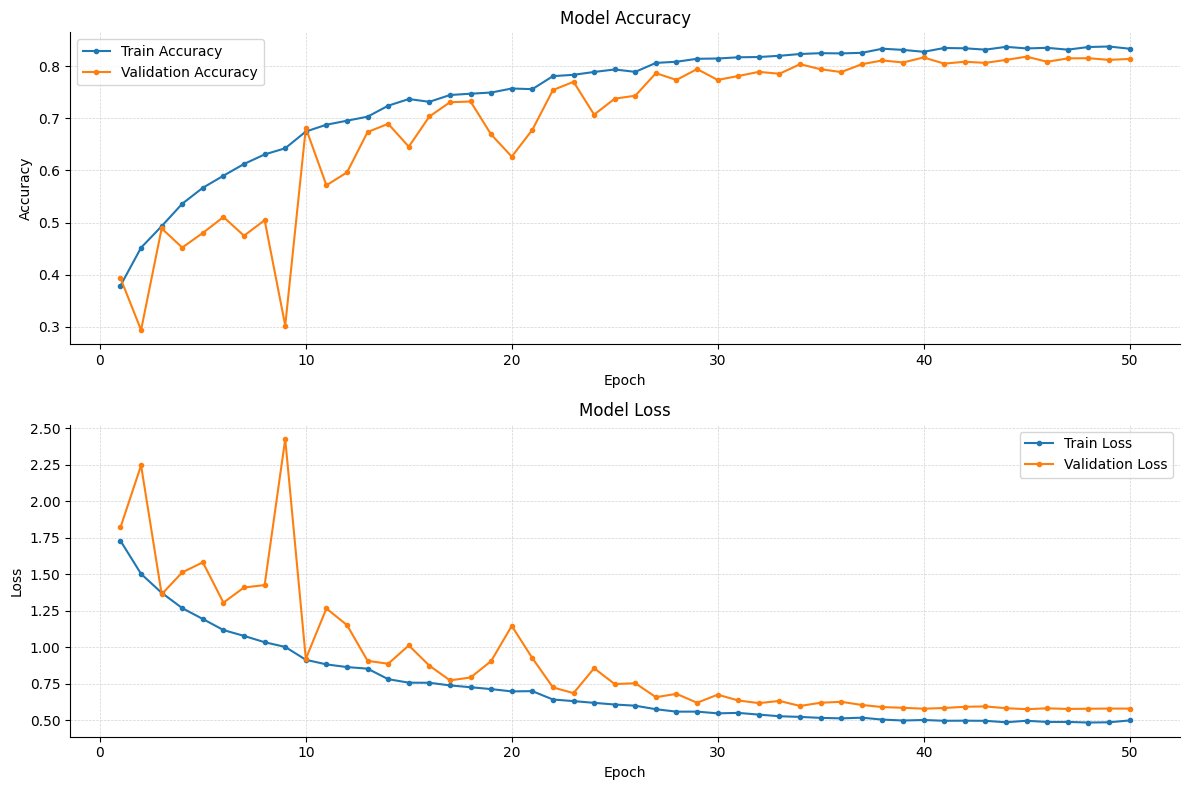

174/174 ━━━━━━━━━━━━━━━━━━━━ 71s 405ms/step - accuracy: 0.8336 - loss: 0.4976 - val_accuracy: 0.8140 - val_loss: 0.5787 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 45.


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_path = '../models/cnn/'
model_name = f'best_garbage_classifier{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.keras'

model_filepath = os.path.join(model_path, model_name)
# 1. Save the best model automatically
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_filepath, 
    monitor='val_accuracy',                   
    mode='max',                               
    save_best_only=True,                      
    verbose=1                                 
)

# 2. Lower learning rate if stuck for 3 epochs
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.5,      
    patience=3,      
    min_lr=0.00001,  
    verbose=1
)

# 3. Stop training entirely if stuck for 7 epochs
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', 
    patience=7,                   # Wait 7 epochs before stopping
    restore_best_weights=True,    # Automatically reload the best weights at the end
    verbose=1
)

# # Create an instance
live_plot = LivePlotCallback()

# 4. Start training (Epochs set to 50, but it will likely stop earlier!)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50, 
    callbacks=[checkpoint_callback, lr_scheduler, early_stopping, live_plot] 
)

### Save history

In [19]:
# 1. Create the logs directory if it doesn't exist yet
os.makedirs('logs', exist_ok=True)

# 2. Convert the history dictionary to a Pandas DataFrame
history_df = pd.DataFrame(history.history)

# 3. Save it as a CSV (index=False prevents adding an extra column of row numbers)
history_df.to_csv('logs/custom_cnn_history.csv', index=False)

print("Training history saved to logs/custom_cnn_history.csv")

Training history saved to logs/custom_cnn_history.csv


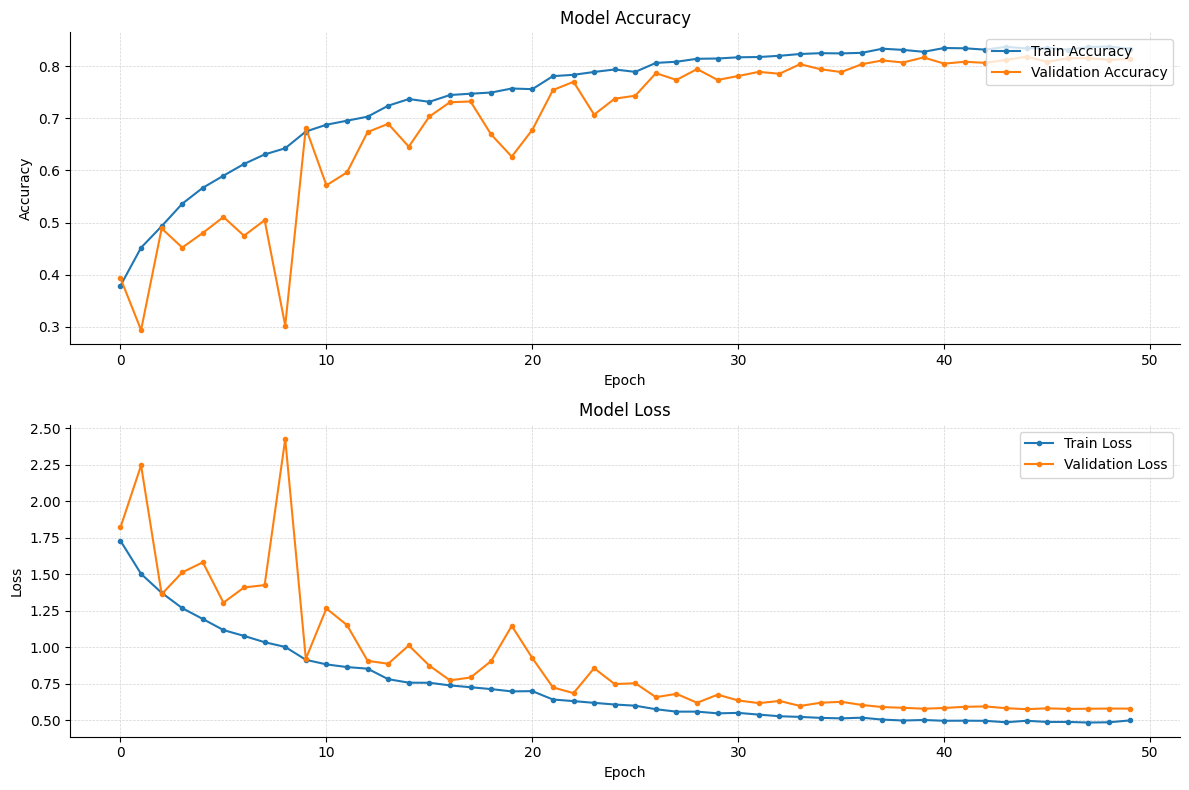

In [20]:
fig, ax = plt.subplots(2,1, figsize=(12, 8))

# Accuracy plot
ax[0].plot(history.history['accuracy'], label='Train Accuracy', marker='.')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', marker='.')
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].legend(loc='upper right')

# Loss plot
ax[1].plot(history.history['loss'], label='Train Loss', marker='.')
ax[1].plot(history.history['val_loss'], label='Validation Loss', marker='.')
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch')
ax[1].legend(loc='upper right')

# Generic settings for both plots
for a in ax:
    a.grid(color='lightgray', linestyle='--', linewidth=0.5)
    for spine in ['top', 'right']:
        a.spines[spine].set_visible(False)
    
plt.tight_layout()
plt.show()

2026-05-09 16:56:16.131029: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


87/87 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


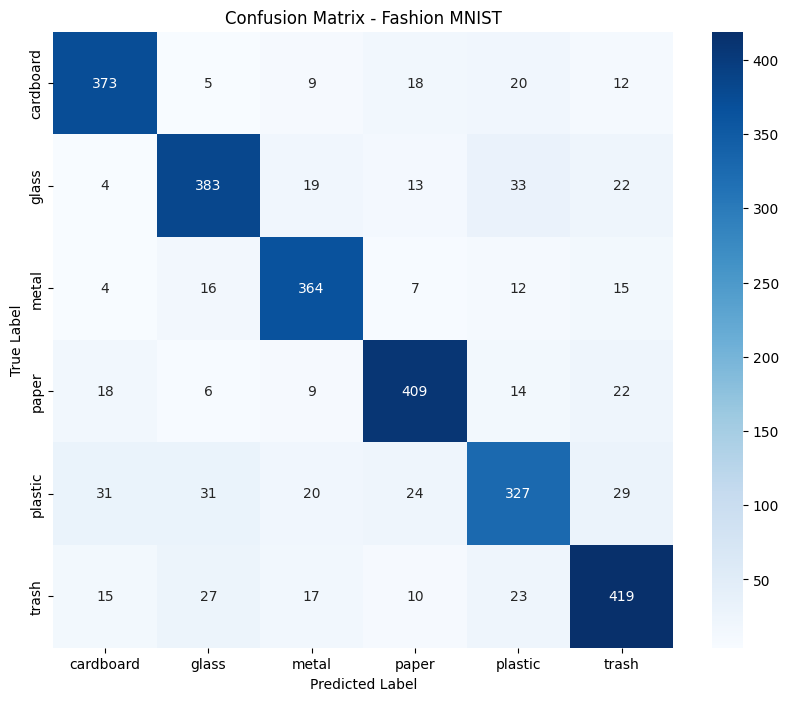

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Get actual labels and predictions from the validation set
# (We unbatch it so we get a flat list of images and labels)
val_images = []
val_labels = []
for images, labels in val_ds.unbatch():
    val_images.append(images.numpy())
    val_labels.append(labels.numpy())

val_images = np.array(val_images)
val_labels = np.array(val_labels)

# Predict
predictions = model.predict(val_images)
predicted_classes = np.argmax(predictions, axis=1)

cm = confusion_matrix(val_labels, predicted_classes)

# Plot
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Fashion MNIST')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


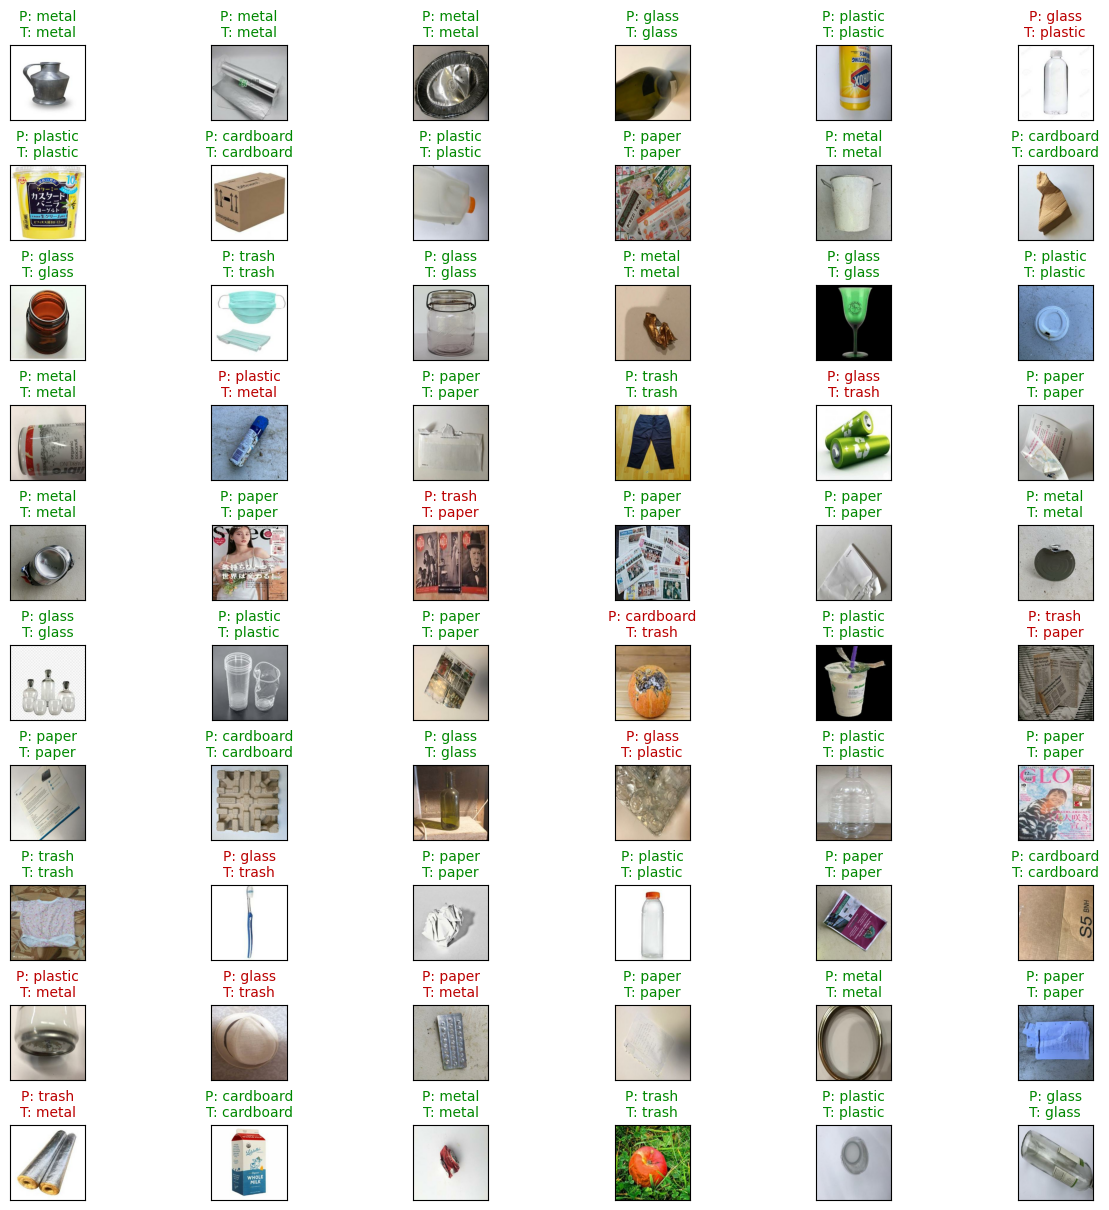

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# 2. Grab a single batch (64 images) from your validation dataset
for images, labels in val_ds.take(1):
    test_images = images.numpy()
    test_labels = labels.numpy()
    break # We only need one batch to get 25 images

# 3. Get predictions for this batch
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)

# 4. Create a 5x5 subplot
fig, axes = plt.subplots(10, 6, figsize=(15, 15)) # Made slightly larger for readability
fig.subplots_adjust(hspace=0.6, wspace=0.3)

# 5. Plot the first 25 images
for i, ax in enumerate(axes.flat):
    # CRITICAL FIX 1: Removed .reshape(28, 28). Your images are already (256, 256, 3)
    # Convert floats back to standard 0-255 integers for plotting
    img = test_images[i].astype("uint8") 
    
    # Check test labels format
    if test_labels[i].ndim > 0:
        true_label = np.argmax(test_labels[i])
    else:
        true_label = int(test_labels[i])
        
    pred_label = predicted_classes[i]

    # Comparison
    if pred_label == true_label:
        color = '#008800'  # Green (Correct)
    else:
        color = '#bb0000'  # Red (Incorrect)

    # CRITICAL FIX 2: Removed cmap='gray' because your images are full color
    ax.imshow(img)
    
    # Display Predicted (P) and True (T) labels on two lines to prevent overlap
    ax.set_title(f'P: {class_names[pred_label]}\nT: {class_names[true_label]}', color=color, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()